# Machine Learning: Modeling the Volatility Smile
Theoretical models like Geometric Brownian Motion assume constant volatility. However, market prices reflect a "Volatility Smile" where implied volatility varies by strike price. 

In this notebook, we apply the IBM Data Science Methodology:
1. **Data Preparation:** We load our real Allianz (ALV.DE) historical data to get a baseline $\sigma$.
2. **Supervised Learning:** We use Scikit-learn's `PolynomialFeatures` and `LinearRegression` to fit a model to the market's implied volatility smile.
3. **Model Evaluation:** We evaluate our ML model using $R^2$ and Mean Squared Error (MSE).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load the Allianz data we fetched earlier
data_path = os.path.abspath('../data/ALV.DE_historical_data.csv')
alv_df = pd.read_csv(data_path, index_col='Date', parse_dates=True)

# Extract the most recent 30-day rolling volatility as our baseline
baseline_vol = alv_df['Rolling_Volatility_30D'].iloc[-1]
current_price = alv_df['Price'].iloc[-1]

print(f"Latest ALV.DE Price: €{current_price:.2f}")
print(f"Baseline Historical Volatility: {baseline_vol * 100:.2f}%")

Latest ALV.DE Price: €347.60
Baseline Historical Volatility: 24.55%


<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\acer\AppData\Local\Temp\ipykernel_36152\243515339.py:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.ylabel('Implied Volatility ($\sigma$)', fontsize=12)


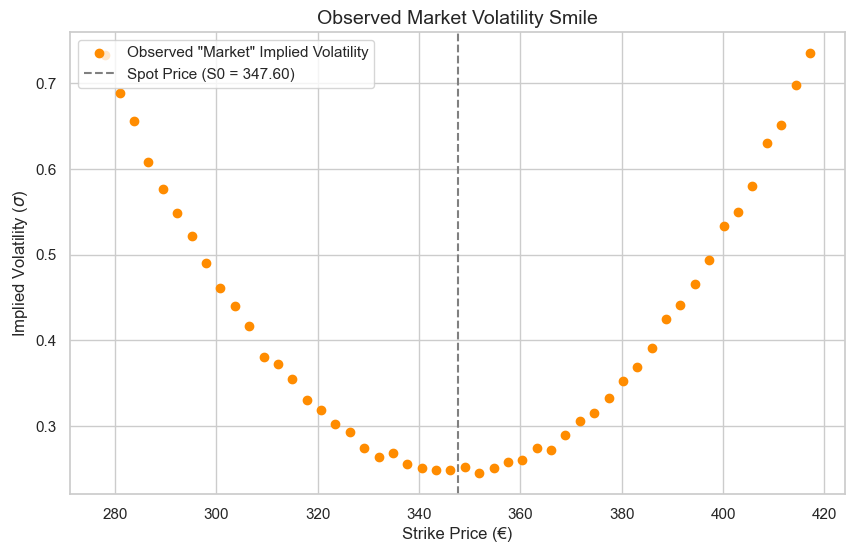

In [3]:
# Generate a range of Strike Prices (K) around the current stock price
strikes = np.linspace(current_price * 0.8, current_price * 1.2, 50)

# Simulate a market Volatility Smile (parabolic shape + some market noise)
# Implied Vol = Baseline Vol + a * (K - S0)^2 + noise
smile_curvature = 0.0001
noise = np.random.normal(0, 0.005, len(strikes))
implied_vols = baseline_vol + smile_curvature * (strikes - current_price)**2 + noise

# Reshape for Scikit-learn
X = strikes.reshape(-1, 1)  # Feature: Strike Price
y = implied_vols            # Target: Implied Volatility

plt.scatter(X, y, color='darkorange', label='Observed "Market" Implied Volatility')
plt.axvline(current_price, color='grey', linestyle='--', label=f'Spot Price (S0 = {current_price:.2f})')
plt.title('Observed Market Volatility Smile', fontsize=14)
plt.xlabel('Strike Price (€)', fontsize=12)
plt.ylabel('Implied Volatility ($\sigma$)', fontsize=12)
plt.legend()
plt.show()

<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\acer\AppData\Local\Temp\ipykernel_36152\2802387057.py:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.ylabel('Implied Volatility ($\sigma$)', fontsize=12)


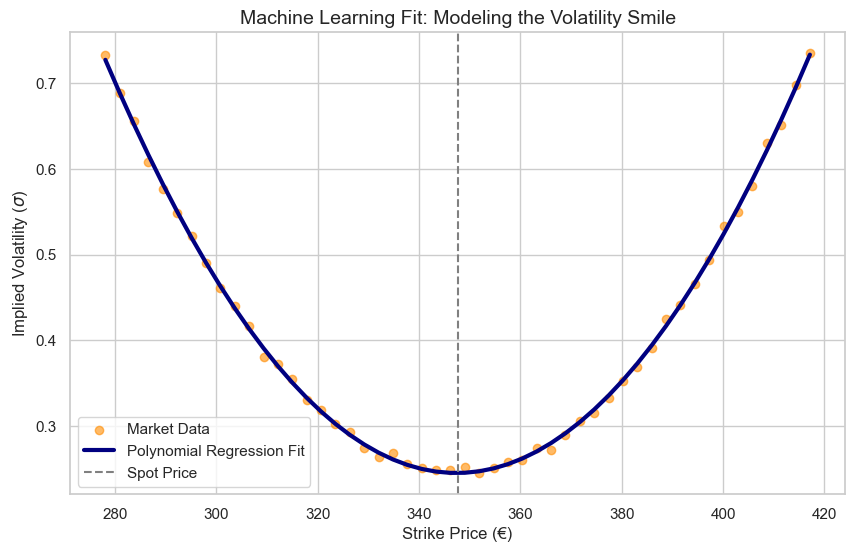

In [4]:
# 1. Feature Engineering: Transform strikes into polynomial features (Degree 2 for a parabola)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# 2. Model Training: Fit the Linear Regression model to the polynomial features
model = LinearRegression()
model.fit(X_poly, y)

# 3. Prediction
y_pred = model.predict(X_poly)

# Plotting the ML Model vs Reality
plt.scatter(X, y, color='darkorange', label='Market Data', alpha=0.6)
plt.plot(X, y_pred, color='navy', linewidth=3, label='Polynomial Regression Fit')
plt.axvline(current_price, color='grey', linestyle='--', label='Spot Price')
plt.title('Machine Learning Fit: Modeling the Volatility Smile', fontsize=14)
plt.xlabel('Strike Price (€)', fontsize=12)
plt.ylabel('Implied Volatility ($\sigma$)', fontsize=12)
plt.legend()
plt.show()

In [5]:
# Calculate evaluation metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("--- Machine Learning Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R-squared (R²):           {r2:.4f}")
print("\nConclusion: An R² close to 1.0 indicates that our polynomial regression")
print("successfully captured the non-linear dynamics of the market's implied volatility.")

--- Machine Learning Model Evaluation ---
Mean Squared Error (MSE): 0.000020
R-squared (R²):           0.9991

Conclusion: An R² close to 1.0 indicates that our polynomial regression
successfully captured the non-linear dynamics of the market's implied volatility.
